In [ ]:
import warnings, os, pickle
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM,
    logging as hf_logging,
)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

hf_logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import networkx as nx
from collections import defaultdict, Counter
from datetime import datetime, timedelta
import math
EMO_MODEL_NAME = "vinai/phobert-base"
LLM_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"


Using device: cuda


In [ ]:
EMOTION_GROUPS: dict[str, dict] = {
    # POSITIVE
    "joy":            {"category": "positive",  "score":  1.0, "guidance": "vui mừng, hạnh phúc", "icon": ("😊", "#f59e0b")},
    "amusement":      {"category": "positive",  "score":  1.0, "guidance": "vui vẻ, hài hước", "icon": ("😄", "#fbbf24")},
    "excitement":     {"category": "positive",  "score":  1.0, "guidance": "hứng khởi, phấn khích", "icon": ("🤩", "#f97316")},
    "optimism":       {"category": "positive",  "score":  1.0, "guidance": "lạc quan, tin tưởng", "icon": ("🌟", "#84cc16")},
    "pride":          {"category": "positive",  "score":  1.0, "guidance": "tự hào, tự tôn", "icon": ("💪", "#10b981")},
    "admiration":     {"category": "positive",  "score":  1.0, "guidance": "kính trọng, ngưỡng mộ", "icon": ("🌸", "#a78bfa")},
    "gratitude":      {"category": "positive",  "score":  1.0, "guidance": "biết ơn, trân trọng", "icon": ("🙏", "#34d399")},
    "relief":         {"category": "positive",  "score":  1.0, "guidance": "thoải mái, an tâm", "icon": ("😌", "#6ee7b7")},
    "approval":       {"category": "positive",  "score":  1.0, "guidance": "đồng ý, ủng hộ", "icon": ("👍", "#4ade80")},
    # AFFECTION
    "love":           {"category": "affection", "score":  1.5, "guidance": "yêu thương, tình cảm", "icon": ("❤️", "#f43f5e")},
    "desire":         {"category": "affection", "score":  1.5, "guidance": "khao khát, mong muốn", "icon": ("💫", "#ec4899")},
    "caring":         {"category": "affection", "score":  1.5, "guidance": "quan tâm, chăm sóc", "icon": ("🤗", "#fb7185")},
    # NEUTRAL
    "realization":    {"category": "neutral",   "score":  0.0, "guidance": "nhận thức, hiểu biết", "icon": ("💡", "#60a5fa")},
    "surprise":       {"category": "neutral",   "score":  0.0, "guidance": "bất ngờ, ngạc nhiên", "icon": ("😮", "#818cf8")},
    "curiosity":      {"category": "neutral",   "score":  0.0, "guidance": "tò mò, khám phá", "icon": ("🔍", "#38bdf8")},
    "neutral":        {"category": "neutral",   "score":  0.0, "guidance": "trung lập, bình thản", "icon": ("😐", "#94a3b8")},
    # CONFUSION
    "confusion":      {"category": "confusion", "score": -0.5, "guidance": "bối rối, nhầm lẫn", "icon": ("🤔", "#fcd34d")},
    # ANXIETY
    "fear":           {"category": "anxiety",   "score": -1.0, "guidance": "sợ hãi, lo lắng", "icon": ("😰", "#7dd3fc")},
    "nervousness":    {"category": "anxiety",   "score": -1.0, "guidance": "bồn chồn, căng thẳng", "icon": ("😟", "#93c5fd")},
    # SADNESS
    "remorse":        {"category": "sadness",   "score": -1.0, "guidance": "hối hận, ăn năn", "icon": ("😔", "#a5b4fc")},
    "embarrassment":  {"category": "sadness",   "score": -1.0, "guidance": "xấu hổ, tự ti", "icon": ("😳", "#fda4af")},
    "disappointment": {"category": "sadness",   "score": -1.0, "guidance": "thất vọng, chán nản", "icon": ("😞", "#6b7280")},
    "sadness":        {"category": "sadness",   "score": -1.0, "guidance": "buồn bã, trầm lắng", "icon": ("😢", "#64748b")},
    "grief":          {"category": "sadness",   "score": -1.0, "guidance": "đau buồn, mất mát", "icon": ("💔", "#475569")},
    # ANGER
    "disgust":        {"category": "anger",     "score": -1.5, "guidance": "ghê tởm, khó chịu", "icon": ("🤢", "#4b5563")},
    "anger":          {"category": "anger",     "score": -1.5, "guidance": "tức giận, bực bội", "icon": ("😠", "#ef4444")},
    "annoyance":      {"category": "anger",     "score": -1.5, "guidance": "phiền phức, khó chịu", "icon": ("😤", "#f87171")},
    "disapproval":    {"category": "anger",     "score": -1.5, "guidance": "bất đồng, phản đối", "icon": ("👎", "#dc2626")},
}


#------------------------------------------------------------------

EMOTIONS = [
    "amusement",
    "excitement",
    "joy",
    "love",
    "desire",
    "optimism",
    "caring",
    "pride",
    "admiration",
    "gratitude",
    "relief",
    "approval",
    "realization",
    "surprise",
    "curiosity",
    "confusion",
    "fear",
    "nervousness",
    "remorse",
    "embarrassment",
    "disappointment",
    "sadness",
    "grief",
    "disgust",
    "anger",
    "annoyance",
    "disapproval",
    "neutral"
]

#---------------------------------------------------------------------

emotion2id = {
    emotion: idx
    for idx, emotion in enumerate(EMOTIONS)
}

id2emotion = {
    idx: emotion
    for idx, emotion in enumerate(EMOTIONS)
}

NUM_EMOTIONS = len(EMOTIONS)


BEHAVIORS = sorted(
    list(set(emo_info["category"] for emo_info in EMOTION_GROUPS.values()))
)

behavior2id = {
    behavior: idx
    for idx, behavior in enumerate(BEHAVIORS)
}

id2behavior = {
    idx: behavior
    for idx, behavior in enumerate(BEHAVIORS)
}

NUM_BEHAVIORS = len(BEHAVIORS)

In [ ]:
import torch
from torch.utils.data import Dataset

class EmotionDataset(Dataset):
    def __init__(self, hf_split, tokenizer,max_len=256):
        self.data = hf_split
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def build_text(self, row):
        if "text" in row:
            return row["text"]
        situation = row.get("situation", "")
        history = row.get("chat_history", "")
        if isinstance(history, list):
            history = " ".join(history)
        return f"Situation: {situation}\nDialogue: {history}"


    def encode_emotions(self, label_ids):
        target = torch.zeros(NUM_EMOTIONS)
        for idx in label_ids:
            target[idx] = 1.0
        return target


    def get_behavior_id(self, label_ids):
        groups = []
        for label_id in label_ids:
            emotion_name = id2emotion[label_id]
            group_name = EMOTION_GROUPS[emotion_name]["category"]
            group_id = behavior2id[group_name]
            groups.append(group_id)
        return Counter(groups).most_common(1)[0][0]


    def __getitem__(self, idx):
        row = self.data[idx]
        text = self.build_text(row)
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        emotion_labels = row["labels"]

        # nếu labels là string
        if isinstance(emotion_labels, str):
            emotion_labels = eval(emotion_labels)

        emotion_tensor = self.encode_emotions(
            emotion_labels
        )

        behavior_id = self.get_behavior_id(
            emotion_labels
        )


        return {

            "input_ids":
                enc["input_ids"].squeeze(0),

            "attention_mask":
                enc["attention_mask"].squeeze(0),

            # multi-label
            "emotion":
                emotion_tensor.float(),

            # single-label
            "behavior":
                torch.tensor(
                    behavior_id,
                    dtype=torch.long
                )
        }

In [ ]:

class EmotionModel(nn.Module):

    def __init__(self, n_emo, n_behavior=None, base_model=EMO_MODEL_NAME):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model)
        h = self.encoder.config.hidden_size
        self.emotion_head = self._head(h, n_emo)
        self.behavior_head = (
            self._head(h, n_behavior)
            if n_behavior is not None else None
        )

    @staticmethod
    def _head(hidden, n_out):
        return nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, n_out),
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls = out.last_hidden_state[:, 0]
        logits = {
            "emotion": self.emotion_head(cls)
        }
        if self.behavior_head is not None:
            logits["behavior"] = self.behavior_head(cls)
        return logits

    @torch.no_grad()
    def predict(
        self,
        text: str,
        tokenizer,
        id2emotion,
        id2behavior=None,
        threshold=0.5
    ):

        self.eval()

        device = next(self.parameters()).device

        batch = tokenizer(
            text,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt",
        )

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        logits = self(
            batch["input_ids"],
            batch["attention_mask"]
        )


        probs = torch.sigmoid(
            logits["emotion"]
        )[0]

        pred_ids = (
            probs > threshold
        ).nonzero(as_tuple=True)[0].tolist()

        emotions = [
            id2emotion[i]
            for i in pred_ids
        ]

        result = {
            "emotion": emotions
        }

        if (
            "behavior" in logits
            and id2behavior is not None
        ):

            behavior_id = logits[
                "behavior"
            ].argmax(-1).item()

            result["behavior"] = (
                id2behavior[behavior_id]
            )

        return result



In [ ]:
import torch
from sklearn.metrics import f1_score, classification_report
def multiclass_accuracy(logits, labels):
    """
    Tính độ chính xác cho bài toán phân loại đa lớp (Multi-class).

    Args:
        logits (torch.Tensor): Output từ model (chưa qua softmax),
                               kích thước [batch_size, num_classes]
        labels (torch.Tensor): Nhãn thực tế, kích thước [batch_size]

    Returns:
        float: Giá trị accuracy của batch đó (0.0 đến 1.0)
    """
    # Lấy index của class có xác suất cao nhất
    preds = torch.argmax(logits, dim=1)

    # So sánh với nhãn thực tế
    correct = (preds == labels).float()

    # Tính trung bình cộng các trường hợp đúng
    acc = correct.mean()

    return acc.item()
def train(model, loader, optimizer, scheduler, device):
    model.train()
    bce = nn.BCEWithLogitsLoss()
    ce = nn.CrossEntropyLoss()

    total_loss, behavior_acc, steps = 0, 0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        emotion_labels = batch["emotion"].to(device)
        behavior_labels = batch["behavior"].to(device)

        logits = model(input_ids, attention_mask)

        # Loss
        loss_emotion = bce(logits["emotion"], emotion_labels)
        loss_behavior = ce(logits["behavior"], behavior_labels)
        loss = (loss_emotion + loss_behavior) / 2

        # Predict Emotion (for F1)
        preds = (torch.sigmoid(logits["emotion"]) > 0.3).int()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(emotion_labels.cpu().numpy())

        behavior_acc += multiclass_accuracy(logits["behavior"], behavior_labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        steps += 1
        avg_prob = torch.sigmoid(logits["emotion"]).mean().item()

        pbar.set_postfix({
            "loss": f"{total_loss/steps:.4f}",
            "beh_acc": f"{behavior_acc/steps:.4f}"
        })

    return {
        "loss": total_loss / steps,
        "behavior_acc": behavior_acc / steps,
        "micro_f1": f1_score(all_labels, all_preds, average="micro"),
        "macro_f1": f1_score(all_labels, all_preds, average="macro")
    }

In [ ]:
@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    bce = nn.BCEWithLogitsLoss()
    ce = nn.CrossEntropyLoss()

    total_loss, behavior_acc, steps = 0, 0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Validation", leave=False)

    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        emotion_labels = batch["emotion"].to(device)
        behavior_labels = batch["behavior"].to(device)

        logits = model(input_ids, attention_mask)

        loss = (bce(logits["emotion"], emotion_labels) + ce(logits["behavior"], behavior_labels)) / 2

        preds = (torch.sigmoid(logits["emotion"]) > 0.5).int()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(emotion_labels.cpu().numpy())

        behavior_acc += multiclass_accuracy(logits["behavior"], behavior_labels)
        total_loss += loss.item()
        steps += 1

        pbar.set_postfix({"loss": f"{total_loss/steps:.4f}", "beh_acc": f"{behavior_acc/steps:.4f}"})

    return {
        "loss": total_loss / steps,
        "behavior_acc": behavior_acc / steps,
        "micro_f1": f1_score(all_labels, all_preds, average="micro"),
        "macro_f1": f1_score(all_labels, all_preds, average="macro")
    }

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

def train_emotion_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=2e-5,
    save_path="best_emotion.pt",
    patience=5,
    device="cuda"
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_micro_f1": [],
        "val_macro_f1": [],
        "val_behavior_acc": []
    }

    model.to(device)

    optimizer = AdamW(model.parameters(), lr=lr)

    total_steps = len(train_loader) * epochs

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    best_val_f1 = -1
    early_stop_counter = 0

    for epoch in range(epochs):
        tqdm.write(f"\n===== Epoch {epoch+1}/{epochs} =====")

        train_metrics = train(
            model,
            train_loader,
            optimizer,
            scheduler,
            device
        )


        val_metrics = validate(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_micro_f1"].append(val_metrics["micro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_behavior_acc"].append(val_metrics["behavior_acc"])

        tqdm.write(
            f"Train | Loss: {train_metrics['loss']:.4f} | "
            f"Beh Acc: {train_metrics['behavior_acc']:.4f}"
        )

        tqdm.write(
            f"Val   | Loss: {val_metrics['loss']:.4f} | "
            f"Beh Acc: {val_metrics['behavior_acc']:.4f} | "
            f"Micro F1: {val_metrics['micro_f1']:.4f} | "
            f"Macro F1: {val_metrics['macro_f1']:.4f}"
        )

        current_score = val_metrics["micro_f1"]

        if current_score > best_val_f1:
            best_val_f1 = current_score

            torch.save({
                "model_state_dict": model.state_dict(),
                "base_model": EMO_MODEL_NAME,
                "n_emo": model.emotion_head[-1].out_features,
                "n_behavior": (
                    model.behavior_head[-1].out_features
                    if model.behavior_head is not None
                    else None
                ),
            }, save_path)

            tqdm.write(f"--> Saved best model with Micro F1: {best_val_f1:.4f}")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            tqdm.write(f"No improvement ({early_stop_counter}/{patience})")

        if early_stop_counter >= patience:
            tqdm.write("Early stopping triggered!")
            break

    tqdm.write("\nTraining finished!")
    return model, history

In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader

from transformers import AutoTokenizer

from huggingface_hub import login

login("")

ds = load_dataset("uitnlp/vigoemotions")


tokenizer = AutoTokenizer.from_pretrained(
    EMO_MODEL_NAME
)

train_ds = EmotionDataset(
    ds["train"],
    tokenizer
)

val_ds = EmotionDataset(
    ds["validation"],
    tokenizer
)

test_ds = EmotionDataset(
    ds["test"],
    tokenizer
)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)


print("Num emotions :", NUM_EMOTIONS)

print("Num behaviors:", NUM_BEHAVIORS)

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16531 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Num emotions : 28
Num behaviors: 7


In [ ]:
model = EmotionModel(
    n_emo=NUM_EMOTIONS,
    n_behavior=NUM_BEHAVIORS
)

emo_model, history = train_emotion_model(
    model,
    train_loader,
    val_loader
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


===== Epoch 1/10 =====


Training:   0%|          | 0/259 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train | Loss: 0.3265 | Beh Acc: 0.8628
Val   | Loss: 0.6843 | Beh Acc: 0.6601 | Micro F1: 0.1494 | Macro F1: 0.0441
--> Saved best model with Micro F1: 0.1494

===== Epoch 10/10 =====


Training:   0%|          | 0/259 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train | Loss: 0.3098 | Beh Acc: 0.8741
Val   | Loss: 0.6867 | Beh Acc: 0.6601 | Micro F1: 0.1531 | Macro F1: 0.0462
--> Saved best model with Micro F1: 0.1531

Training finished!


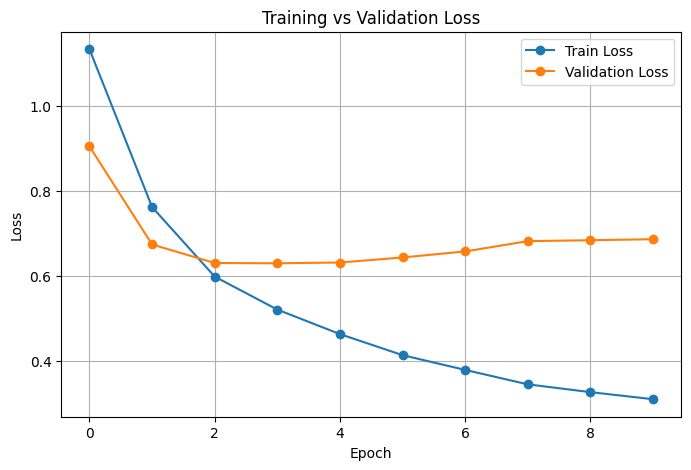

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

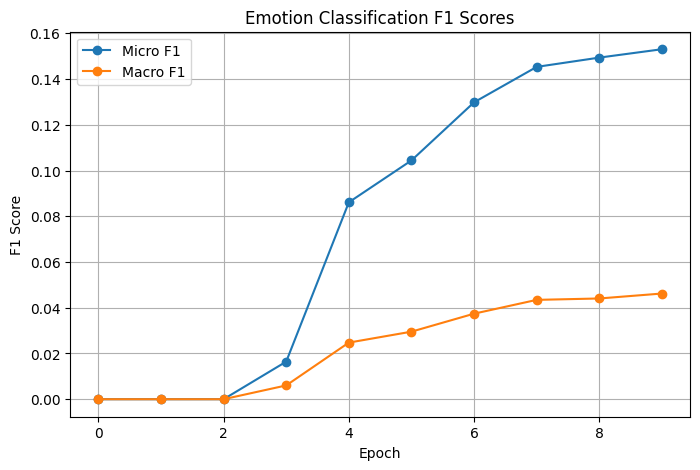

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(
    history["val_micro_f1"],
    marker="o",
    label="Micro F1"
)

plt.plot(
    history["val_macro_f1"],
    marker="o",
    label="Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")

plt.title("Emotion Classification F1 Scores")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
@torch.no_grad()
def test(model, loader, device, emotion_names=None):
    model.eval()
    bce = nn.BCEWithLogitsLoss()
    ce = nn.CrossEntropyLoss()

    total_loss, behavior_acc, steps = 0, 0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Testing", leave=False)

    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        emotion_labels = batch["emotion"].to(device)
        behavior_labels = batch["behavior"].to(device)

        logits = model(input_ids, attention_mask)
        loss = (bce(logits["emotion"], emotion_labels) + ce(logits["behavior"], behavior_labels)) / 2

        preds = (torch.sigmoid(logits["emotion"]) > 0.5).int()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(emotion_labels.cpu().numpy())

        behavior_acc += multiclass_accuracy(logits["behavior"], behavior_labels)
        total_loss += loss.item()
        steps += 1

    micro_f1 = f1_score(all_labels, all_preds, average="micro")
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    results = {
        "loss": total_loss / steps,
        "behavior_acc": behavior_acc / steps,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1
    }

    print("\n" + "="*30 + "\n      TEST SUMMARY\n" + "="*30)
    for k, v in results.items(): print(f"{k:<15}: {v:.4f}")


    return results

In [ ]:
test_results = test(
    model=emo_model,
    loader=test_loader,
    device=device,
    emotion_names=EMOTIONS
)

Testing:   0%|          | 0/33 [00:00<?, ?it/s]


      TEST SUMMARY
loss           : 0.6213
behavior_acc   : 0.6850
micro_f1       : 0.1524
macro_f1       : 0.0457


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

def get_grouped_report(y_true, y_pred, emotion_list, emotion_groups):
    """
    y_true, y_pred: Dạng list các ID hoặc ma trận nhãn (n_samples, n_emotions)
    emotion_list: Danh sách 28 emotions
    emotion_groups: Dictionary mapping emotion -> category
    """

    # mapping từ ID của emotion sang Category
    id_to_category = {
        i: emotion_groups[emo]["category"]
        for i, emo in enumerate(emotion_list)
    }

    all_categories = sorted(list(set(info["category"] for info in emotion_groups.values())))
    cat_to_id = {cat: i for i, cat in enumerate(all_categories)}

    # 28 emos = 7 behav
    y_true_grouped = []
    y_pred_grouped = []

    for i in range(len(y_true)):
        true_cats = [0] * len(all_categories)
        pred_cats = [0] * len(all_categories)

        for emo_id in range(len(emotion_list)):
            cat_idx = cat_to_id[id_to_category[emo_id]]
            if y_true[i][emo_id] == 1: true_cats[cat_idx] = 1
            if y_pred[i][emo_id] == 1: pred_cats[cat_idx] = 1

        y_true_grouped.append(true_cats)
        y_pred_grouped.append(pred_cats)

    report = classification_report(
        y_true_grouped,
        y_pred_grouped,
        target_names=all_categories,
        zero_division=0
    )
    return report

grouped_report = get_grouped_report(all_labels, all_preds, EMOTIONS, EMOTION_GROUPS)
print(grouped_report)

              precision    recall  f1-score   support

   affection       0.00      0.00      0.00       307
       anger       0.93      0.36      0.52       536
     anxiety       0.00      0.00      0.00       151
   confusion       0.00      0.00      0.00        84
     neutral       0.00      0.00      0.00       369
    positive       0.00      0.00      0.00       888
     sadness       0.89      0.51      0.65       528

   micro avg       0.91      0.16      0.27      2863
   macro avg       0.26      0.12      0.17      2863
weighted avg       0.34      0.16      0.22      2863
 samples avg       0.22      0.20      0.21      2863

